In [2]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_
from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

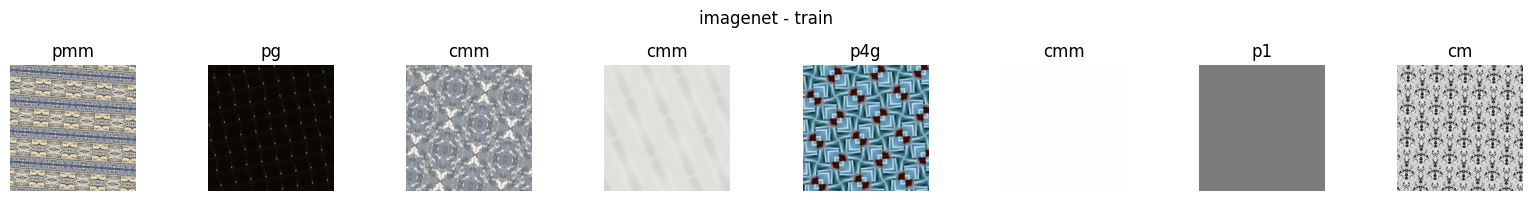

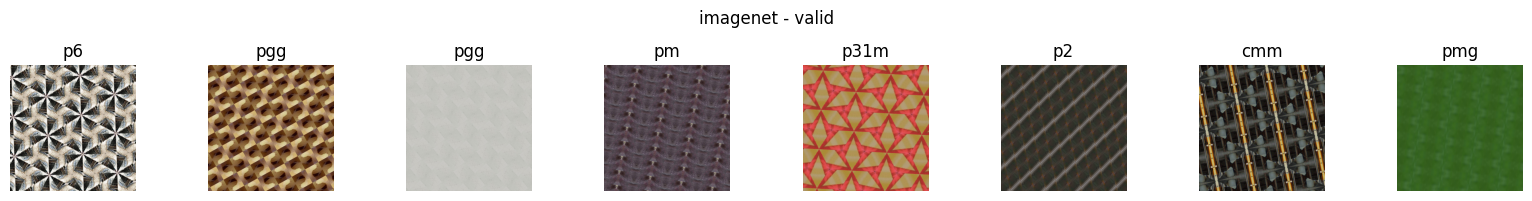

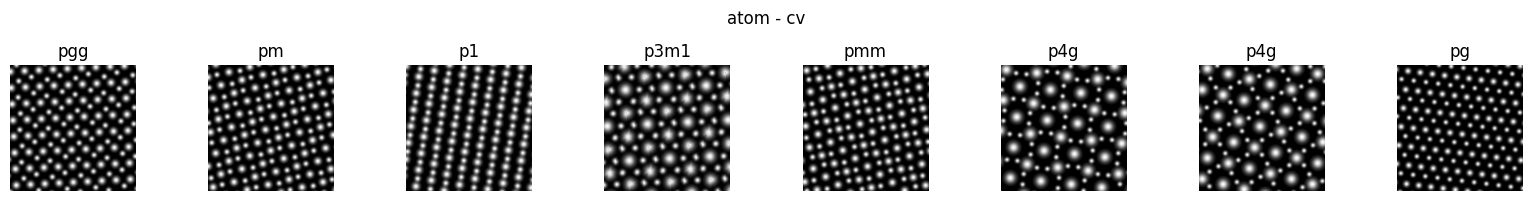

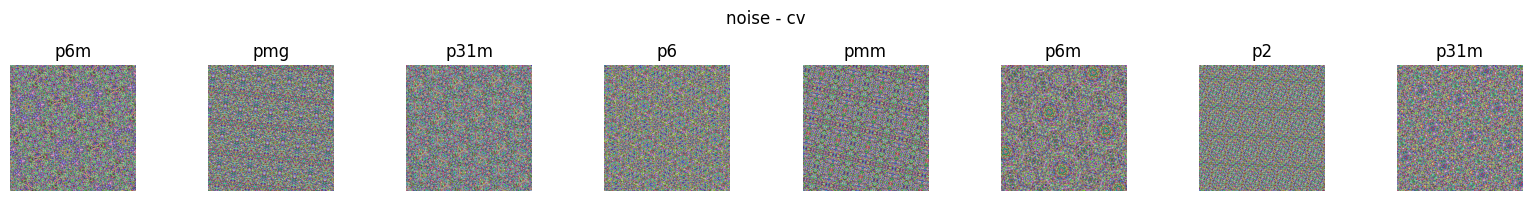

In [3]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=300, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# # atom
atom_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# # noise
noise_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
noise_dl = DataLoader(noise_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')

In [4]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[0,1])
# model

torch.Size([2, 17])


In [5]:
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '05242024-benchmark-resnet50_from_scratch-v5_10m'

# train

In [6]:
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [7]:
device = torch.device('cuda:0')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_dl_list=[atom_dl, noise_dl], cv_name_list=['atom', 'noise'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir='../../../saved_models/', tracking=True)

Epoch: 1/20


  0%|          | 0/28561 [00:00<?, ?it/s]

  6%|▌         | 1748/28561 [2:31:50<38:49:08,  5.21s/it]


KeyboardInterrupt: 